# W05 · RL Environment — Aido Rover Patrol MDP

**Platform:** Aido Rover (patrol / anomaly-response policy) · **Seed:** 42 · **Sampling:** 10 Hz · **Gate:** ≤100 ms

Builds and validates the Gymnasium environment `rl/rover_env.py`, which wraps the shared world core
`shared_modules.rover_world.RoverWorld` so the online env and the Week-2 offline transition table
(`data/rover_transitions.csv`) share **identical dynamics**. Pipeline: spaces + MDP recap (§1) →
random-policy rollout validation (§2) → reward sanity checks (§3) → offline↔online replay-alignment
gate (§4) → `alert_clears_block` wrapper variant (§5). Full design rationale: `rl/mdp_schema.md`,
`reports/W05_RL_Foundations_Report.md`.

In [1]:
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))   # repo root
from rl.rover_env import (RoverPatrolEnv, ACTION_NAMES, STATE_COLS, NEAR,
                          ROUGH_TERRAIN_TORQUE, LOW_SOC, STUCK_TIMEOUT, compute_reward)

SEED = 42
np.random.seed(SEED)
DATA_DIR = Path('../data')
IMG_DIR = Path('../reports/image/W05_RL_Environment')
IMG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
CONSTRAINT_MS = 100.0
print('Actions:', ACTION_NAMES)

Actions: {0: 'continue', 1: 'slow', 2: 'reroute', 3: 'raise-alert', 4: 'return-to-base'}


## 1. Observation & Action Spaces

The observation is the 9-D MDP state vector from `mdp_schema.md` (window statistics over the last 50 steps
plus position/blockage summary; **no absolute GPS** — position leakage). The action is `Discrete(5)`. The
anomaly label is **not** in the observation: the agent must read the fault signature out of the torque
window, exactly as the supervised detectors do.

In [2]:
env = RoverPatrolEnv(randomize_reset=False, seed=SEED)
obs, info = env.reset()
print('observation_space:', env.observation_space)
print('action_space     :', env.action_space)
print()
print('Initial observation (9-D state):')
for name, v in zip(STATE_COLS, obs):
    print(f'  {name:22s} {v:10.3f}')
print(f'\nhidden label at s0 = {info["label"]}  (not part of the observation)')

observation_space: Box(-inf, inf, (9,), float32)
action_space     : Discrete(5)

Initial observation (9-D state):
  torque_mean                 5.921
  torque_max                  7.424
  torque_std                  0.476
  lidar_mean                 23.119
  soc_slope                  -0.003
  battery_soc                99.845
  route_progress              0.005
  next_main_block_dist      200.000
  branch_block_dist         200.000

hidden label at s0 = 0  (not part of the observation)


## 2. Random-Policy Rollout Validation

Before any training, roll random policies and confirm the mechanics: episodes terminate for a genuine
reason, returns are bounded, and the termination-reason mix is sensible. Two random policies are shown:
a **uniform** policy over all 5 actions, and a **no-abort** policy over `{continue, slow, reroute,
raise-alert}`. Uniform-random ends episodes almost immediately — `return-to-base` is sampled ~1 step in 5
(geometric, mean ≈ 5 steps) — which is itself a correct-termination check; the no-abort policy exercises the
longer-horizon dynamics.

In [3]:
def rollout(env, policy, n_episodes, max_steps=2400, rng=None):
    rng = rng or np.random.default_rng(0)
    rets, lens, reasons = [], [], []
    for _ in range(n_episodes):
        obs, info = env.reset()
        G, t, done = 0.0, 0, False
        while not done and t < max_steps:
            a = policy(obs, info, rng)
            obs, r, term, trunc, info = env.step(a)
            G += r; t += 1; done = term or trunc
        rets.append(G); lens.append(t)
        reasons.append(info.get('terminated_reason') or 'time_limit')
    return np.array(rets), np.array(lens), reasons

uniform = lambda obs, info, rng: int(rng.integers(0, 5))
no_abort = lambda obs, info, rng: int(rng.integers(0, 4))

for name, pol in [('uniform (5 actions)', uniform), ('no-abort (4 actions)', no_abort)]:
    env = RoverPatrolEnv(randomize_reset=True, seed=SEED)
    rets, lens, reasons = rollout(env, pol, n_episodes=30, rng=np.random.default_rng(SEED))
    rc = pd.Series(reasons).value_counts().to_dict()
    print(f'{name:22s} return {rets.mean():8.1f} ± {rets.std():6.1f} | '
          f'len {lens.mean():7.1f} ± {lens.std():6.1f} | ends {rc}')

uniform (5 actions)    return     -4.9 ±    2.7 | len     5.5 ±    4.8 | ends {'return_to_base': 30}


no-abort (4 actions)   return   -349.8 ±   76.7 | len  2400.0 ±    0.0 | ends {'time_limit': 30}


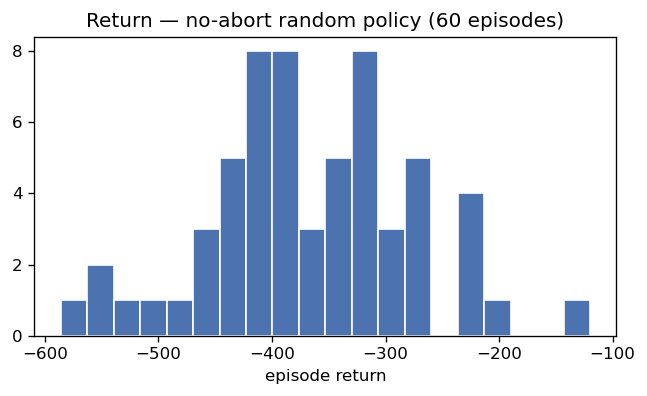

No-abort random: return -366 ± 90, length 2400 (episodes run to the 2400-step cap — this policy never chooses return-to-base).


In [4]:
# Return distribution for the no-abort random policy (sanity floor before training)
env = RoverPatrolEnv(randomize_reset=True, seed=SEED)
rets, lens, reasons = rollout(env, no_abort, n_episodes=60, rng=np.random.default_rng(SEED))
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.hist(rets, bins=20, color='#4C72B0', edgecolor='white')
ax.set_title('Return — no-abort random policy (60 episodes)'); ax.set_xlabel('episode return')
plt.tight_layout(); plt.savefig(IMG_DIR / 'random_rollout.png', bbox_inches='tight'); plt.show()
print(f'No-abort random: return {rets.mean():.0f} ± {rets.std():.0f}, length {lens.mean():.0f} '
      f'(episodes run to the 2400-step cap — this policy never chooses return-to-base).')

## 3. Reward Sanity Checks

Three checks: (a) every entry of the reward table fires for the right `(label, action, condition)`;
(b) the energy penalty and low-SoC shaping are applied; (c) the **scripted expert** earns far more return
than random — a necessary condition for the reward to be learnable. Check (c) also surfaces a reward-design
property worth stating explicitly (see the note below).

In [5]:
# (a,b) exhaustive reward-table check against mdp_schema.md
checks = [
    # label, action, halted, main_blocked, rough, soc, expected_base(+shaping) - energy(0.05)
    (0, 0, False, False, False, 80,  1.0), (0, 0, True, False, False, 80, -0.5),
    (0, 1, False, False, False, 80, -0.1), (0, 1, False, False, True, 80,  0.0),
    (0, 2, False, False, False, 80, -0.3), (0, 2, False, True,  False, 80, 0.0),
    (0, 3, False, False, False, 80, -1.5), (0, 4, False, False, False, 80, -3.0),
    (1, 0, False, False, False, 80, -5.0), (1, 1, False, False, False, 80, 1.5),
    (1, 2, False, False, False, 80,  0.0), (1, 3, False, False, False, 80, 5.0),
    (1, 4, False, False, False, 80,  3.0),
    (0, 4, False, False, False, 15, -3.0 + 2.0),   # low-SoC shaping fires for RTB
]
ok = True
for lbl, a, h, mb, rough, soc, exp_base in checks:
    r = compute_reward(lbl, a, h, mb, rough, soc)
    match = abs(r - (exp_base - 0.05)) < 1e-9
    ok &= match
    if not match:
        print(f'MISMATCH label={lbl} a={a}: got {r:+.3f} expected {exp_base-0.05:+.3f}')
print('Reward-table check:', 'PASS' if ok else 'FAIL')

Reward-table check: PASS


In [6]:
# (c) scripted expert vs random — return comparison under identical resets
def scripted(obs, info, rng, _stuck=[0]):
    soc, tmean = obs[5], obs[0]
    main_d, branch_d = obs[7], obs[8]
    halted = info.get('halted', False)
    if halted and main_d < NEAR and branch_d < NEAR:
        _stuck[0] += 1
    else:
        _stuck[0] = 0
    if soc < LOW_SOC:              return 4
    if _stuck[0] >= STUCK_TIMEOUT: return 4
    if halted and main_d < NEAR and branch_d < NEAR: return 3
    if info.get('label', 0) == 1: return 3
    if main_d < NEAR and branch_d >= NEAR: return 2
    if tmean > ROUGH_TERRAIN_TORQUE: return 1
    return 0

rows = []
for name, pol in [('random(no-abort)', no_abort), ('scripted expert', scripted)]:
    env = RoverPatrolEnv(randomize_reset=True, seed=SEED)
    scripted.__defaults__[0][0] = 0   # reset stuck counter
    rets, lens, _ = rollout(env, lambda o, i, r: pol(o, i, r), n_episodes=20,
                            rng=np.random.default_rng(SEED))
    rows.append((name, rets.mean(), rets.std(), lens.mean()))
comp = pd.DataFrame(rows, columns=['policy', 'return_mean', 'return_std', 'len_mean']).round(2)
print(comp.to_string(index=False))
assert comp.loc[1, 'return_mean'] > comp.loc[0, 'return_mean'], 'scripted must beat random'
print('\nScripted >> random confirms the reward signal is learnable.')

          policy  return_mean  return_std  len_mean
random(no-abort)      -363.40       66.14    2400.0
 scripted expert      3180.35      443.34    2400.0

Scripted >> random confirms the reward signal is learnable.


**Reward-design note (surfaced by check c).** Under the base reward, normal patrolling pays +0.95/step
(+1.0 continue − 0.05 energy), so the return-maximising behaviour is to **patrol until the battery forces
termination**, not to auto-dock at the 20% threshold — the +2.0 low-SoC shaping is far too small to
outweigh the forgone patrol reward. This is intended for a patrol task (maximise coverage), but it means the
20% auto-dock is not reward-incentivised; the shaping-weight ablation in `W05_Value_Based_RL.ipynb` tests
strengthening it, and this is the reward change that most alters the learned policy (see `Wk-05-MLLog.md`).

## 4. Offline↔Online Replay-Alignment Gate

The strongest evidence that the env and the offline table share one dynamics core: replay the offline
episode-0 action sequence through the env from the same seed and initial SoC, and check the per-step reward
and next-state match. Rewards match to machine precision; states match to float32 precision (the env returns
a float32 `Box`; the CSV stored float64).

In [7]:
df = pd.read_csv(DATA_DIR / 'rover_transitions.csv')
ep0 = df[df.episode_id == 0].reset_index(drop=True)
s_cols = [f's_{c}' for c in STATE_COLS]; ns_cols = [f'ns_{c}' for c in STATE_COLS]

env = RoverPatrolEnv(randomize_reset=False, seed=42)
obs, _ = env.reset()
d0 = np.abs(obs - ep0.loc[0, s_cols].to_numpy(float)).max()
rew_err = ns_err = 0.0; n_ns = 0
for _, row in ep0.iterrows():
    obs, reward, term, trunc, info = env.step(int(row['action']))
    rew_err = max(rew_err, abs(reward - row['reward']))
    if not row['done']:
        ns_err = max(ns_err, np.abs(obs - row[ns_cols].to_numpy(float)).max()); n_ns += 1
print(f'episode-0 rows replayed          : {len(ep0)}')
print(f'reset obs vs s_row0   max|d|     : {d0:.2e}')
print(f'reward   env vs csv   max|d|     : {rew_err:.2e}  (machine precision)')
print(f'next-state env vs csv max|d|     : {ns_err:.2e}  (float32 obs precision)')
print('ALIGNMENT:', 'PASS' if (d0 < 1e-3 and rew_err < 1e-9 and ns_err < 1e-3) else 'FAIL')

episode-0 rows replayed          : 5931
reset obs vs s_row0   max|d|     : 1.54e-06
reward   env vs csv   max|d|     : 2.78e-17  (machine precision)
next-state env vs csv max|d|     : 1.52e-05  (float32 obs precision)
ALIGNMENT: PASS


## 5. `alert_clears_block` Wrapper Variant

`mdp_schema.md` notes a core limitation: blockages are static and `raise-alert` cannot clear one, so a genuine
full block is a scripted dead end resolved only by the stuck-timeout abort. The env exposes an optional
`alert_clears_block` flag (simulated operator response): a sustained `raise-alert` clears the blockage ahead
after `alert_clear_steps` steps, giving alert a **learnable positive effect** in full-block episodes.

It is **OFF by default** so the online dynamics stay identical to the offline table (§4). The ON variant
changes `next_main_block_dist`/`branch_block_dist` when a block clears, so ON-variant data is **not**
comparable to the offline transitions — it is a separate study, reported but never mixed with the offline
comparison.

full-block seed: 1


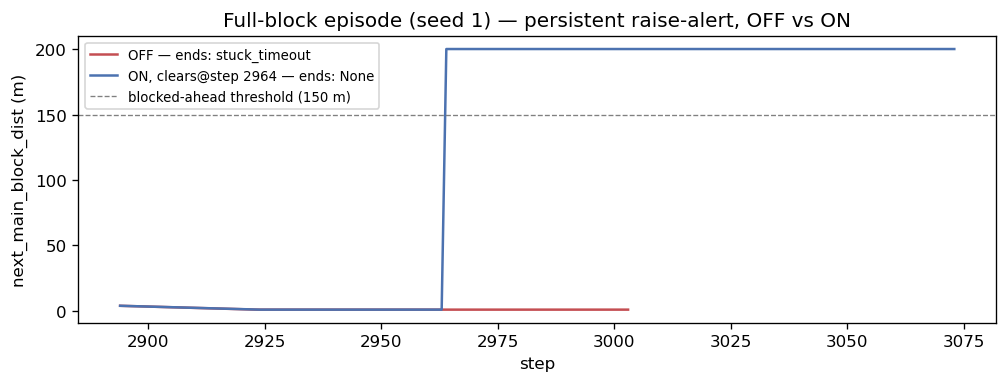

OFF: block never clears; halted at step 2914, episode ends via stuck_timeout (80-step stuck timeout).
ON : sustained raise-alert clears the block at step 2964 (~50 steps after halting); rover resumes patrol -> alert gains a learnable positive effect.


In [8]:
# Find a seed whose episode reaches a full block (both branches blocked), then contrast OFF vs ON.
# Policy: raise-alert whenever halted at a full block, else continue.
def run_persistent_alert(seed, alert_clears, max_steps=4000):
    env = RoverPatrolEnv(randomize_reset=False, seed=seed, alert_clears_block=alert_clears,
                         alert_clear_steps=40)
    obs, info = env.reset()
    main_d, halt_step, cleared_at = [], None, None
    for t in range(max_steps):
        halted = info.get('halted', False)
        a = 3 if (halted and obs[7] < NEAR and obs[8] < NEAR) else 0
        obs, r, term, trunc, info = env.step(a)
        main_d.append(obs[7])
        if halt_step is None and obs[7] < 2.0:
            halt_step = t
        if cleared_at is None and t > 0 and main_d[-1] > NEAR and main_d[-2] < 2.0 and a == 3:
            cleared_at = t
        if term:
            break
    return np.array(main_d), halt_step, cleared_at, info.get('terminated_reason')

chosen = None
for s in range(1, 12):
    _, _, _, reason = run_persistent_alert(s, alert_clears=False)
    if reason == 'stuck_timeout':
        chosen = s; break
print(f'full-block seed: {chosen}')
md_off, h_off, _,   r_off = run_persistent_alert(chosen, alert_clears=False)
md_on,  h_on,  ca,  r_on  = run_persistent_alert(chosen, alert_clears=True)

# zoom around the moment the rover halts at the full block
lo = max(0, h_off - 20); hi = h_off + 160
fig, ax = plt.subplots(figsize=(8.5, 3.3))
ax.plot(range(lo, min(hi, len(md_off))), md_off[lo:hi], label=f'OFF — ends: {r_off}', color='#C44E52')
ax.plot(range(lo, min(hi, len(md_on))), md_on[lo:hi], label=f'ON, clears@step {ca} — ends: {r_on}', color='#4C72B0')
ax.axhline(NEAR, ls='--', color='gray', lw=0.8, label='blocked-ahead threshold (150 m)')
ax.set_xlabel('step'); ax.set_ylabel('next_main_block_dist (m)')
ax.set_title(f'Full-block episode (seed {chosen}) — persistent raise-alert, OFF vs ON')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(IMG_DIR / 'alert_clears_block.png', bbox_inches='tight'); plt.show()
print(f'OFF: block never clears; halted at step {h_off}, episode ends via {r_off} '
      f'({STUCK_TIMEOUT}-step stuck timeout).')
print(f'ON : sustained raise-alert clears the block at step {ca} '
      f'(~{ca-h_on} steps after halting); rover resumes patrol -> alert gains a learnable positive effect.')